# Fracture Fixation Nails – Part 2: Problems and Healing
Continues from `fracture_fixation_fda_01_download_and_verify.ipynb`, which downloaded all 37,835 FDA reports for product code HSB (intramedullary nails) and verified them against the FDA's own counts.

## Step 4 – Load the data and see what goes wrong with the nails
The saved table is reloaded and checked against notebook 1. Then the FDA's own coded **device problems** are counted (each term once per report; a report can list several, so percentages can add up to more than 100%).

**Note on deaths:** many nail patients are elderly people with hip fractures. A death reported after nail surgery is often caused by age and other illnesses, not necessarily by the device.

**Gates:** row count and event-type counts match notebook 1 · reports with a coded device problem + reports without one = total.

In [1]:
# 4.1 Load the nail reports, check them against notebook 1, and count the coded device problems
from google.colab import drive
drive.mount('/content/drive')
import re
import pandas as pd

BASE  = '/content/drive/MyDrive/fracture-fixation-fda'
CLEAN = f'{BASE}/data/clean'
FIG   = f'{BASE}/figures'

def gate(condition, message):
    """Stop the notebook if a check fails; print a pass line if it succeeds."""
    if not condition:
        raise AssertionError('GATE FAILED: ' + message)
    print('GATE PASSED:', message)

TOTAL  = 37835                                                            # from notebook 1
EVENTS = {'Injury': 25103, 'Malfunction': 12477, 'Death': 115, 'Other': 108, '': 32}

nails = pd.read_csv(f'{CLEAN}/nail_reports.csv', dtype=str, keep_default_na=False)
nails['date_received'] = pd.to_datetime(nails['date_received'])
nails['year'] = nails['date_received'].dt.year

gate(len(nails) == TOTAL, f'loaded {len(nails):,} reports, same as notebook 1')
gate(nails['report_key'].is_unique, 'report keys are unique')
gate(nails['event_type'].value_counts().to_dict() == EVENTS, 'event-type counts match notebook 1 exactly')

def terms_per_report(column):
    """One row per (report, term); a term is counted once per report."""
    t = nails[['report_key', column]].copy()
    t[column] = t[column].str.split('; ')
    t = t.explode(column)
    t = t[t[column].notna() & (t[column].str.strip() != '')]
    return t.drop_duplicates(['report_key', column])

device_terms = terms_per_report('product_problems')
with_dev = device_terms['report_key'].nunique()
without_dev = (nails['product_problems'].str.strip() == '').sum()
gate(with_dev + without_dev == TOTAL, f'device-problem coverage adds up ({with_dev:,} + {without_dev:,} = {TOTAL:,})')

print('\nEvent types (% of all reports):')
print((nails['event_type'].replace('', '(blank)').value_counts(normalize=True) * 100).round(1).to_string())

top_dev = device_terms['product_problems'].value_counts().head(15)
print('\nTop 15 device problems:')
print(pd.DataFrame({'reports': top_dev, '% of reports': (top_dev / TOTAL * 100).round(1)}).to_string())

Mounted at /content/drive
GATE PASSED: loaded 37,835 reports, same as notebook 1
GATE PASSED: report keys are unique
GATE PASSED: event-type counts match notebook 1 exactly
GATE PASSED: device-problem coverage adds up (37,668 + 167 = 37,835)

Event types (% of all reports):
event_type
Injury         66.3
Malfunction    33.0
Death           0.3
Other           0.3
(blank)         0.1

Top 15 device problems:
                                                        reports  % of reports
product_problems                                                             
Adverse Event Without Identified Device or Use Problem     9497          25.1
Break                                                      8252          21.8
Fracture                                                   3052           8.1
Device-Device Incompatibility                              2967           7.8
Migration                                                  2310           6.1
Migration or Expulsion of Device           

## Step 5 – What happened to the patients
The FDA's coded **patient problems** are counted (each term once per report). Terms that mean *no harm or no usable information* ("No Patient Involvement", "No Known Impact…", "No Clinical Signs…", "Insufficient Information", "No Information", "No Code Available", "…Term/Code Not Available", "Not Applicable") are counted separately.

The top 25 patient problems are listed so that clinical categories (Step 6) can be built from what the data actually contains.

**Gates:** reports with an actual patient problem + reports with only "no harm" terms + reports with no patient term = total · every percentage is between 0 and 100.

In [3]:
# 5.1 Count the coded patient problems, separating "no harm / no information" terms
NO_HARM = re.compile(r'^No Patient Involvement$|^No Known Impact|^No Clinical Signs|^Insufficient Information$'
                     r'|^No Consequences|^No Information$|^No Code Available$|Term/Code Not Available|^Not Applicable$'
                     r'|^Unknown \(for use when', re.I)

patient_terms = terms_per_report('patient_problems')
patient_terms['no_harm'] = patient_terms['patient_problems'].str.contains(NO_HARM)
harm = patient_terms[~patient_terms['no_harm']]

harmed_keys    = set(harm['report_key'])
any_term_keys  = set(patient_terms['report_key'])
only_no_harm   = any_term_keys - harmed_keys
no_term        = TOTAL - len(any_term_keys)
gate(len(harmed_keys) + len(only_no_harm) + no_term == TOTAL,
     f'{len(harmed_keys):,} with a patient problem + {len(only_no_harm):,} no-harm only + {no_term:,} no term = {TOTAL:,}')

top_harm = harm['patient_problems'].value_counts().head(25)
pct = top_harm / TOTAL * 100
gate(pct.between(0, 100).all(), 'all percentages between 0 and 100')

print(f'\nReports describing an actual patient problem: {len(harmed_keys):,} ({len(harmed_keys) / TOTAL * 100:.1f}%)')
print('\nTop 25 patient problems:')
print(pd.DataFrame({'reports': top_harm, '% of reports': pct.round(1)}).to_string())

GATE PASSED: 19,813 with a patient problem + 17,860 no-harm only + 162 no term = 37,835
GATE PASSED: all percentages between 0 and 100

Reports describing an actual patient problem: 19,813 (52.4%)

Top 25 patient problems:
                                      reports  % of reports
patient_problems                                           
Failure of Implant                       3751           9.9
Pain                                     3644           9.6
Nonunion/Delayed-union Bone Fracture     3416           9.0
Bone Fracture(s)                         2517           6.7
Limb Fracture                            1512           4.0
Unspecified Infection                    1173           3.1
Impaired Healing                          707           1.9
Injury                                    671           1.8
Implant Pain                              624           1.6
Post Operative Wound Infection            511           1.4
Fall                                      413           1

## Step 6 – Group the patient problems into clinical categories
Built from the actual top patient problems (Step 5), checked in this order (first match wins):

| Category | Keywords |
|---|---|
| Death | death |
| Further surgery or treatment | surgical procedure, reoperation, revision |
| Foreign body left in patient | foreign body, embedded |
| Bone not healing (non-union, delayed union, malunion) | nonunion, delayed, malunion, impaired healing |
| Implant failure or loosening | failure of implant, loosening, osteolysis |
| New fracture or bone damage | fracture, perforation, bone |
| Infection, wound or tissue death | infection, wound, necrosis, abscess, osteomyelitis, sepsis |
| Nerve, vessel or soft-tissue injury | nerve, vascular, vessel, tissue, embolism, thrombosis, bleeding, haematoma |
| Falls, mobility or limb-length problems | fall, asymmetry, limb length, ambulation, gait, deformity, dislocation |
| Pain, stiffness or loss of motion | pain, discomfort, range of motion, stiffness, swelling |

*Clinical review:* after a first run, terms such as arthralgia, inadequate osseointegration, Staphylococcus aureus, muscle/tendon damage, joint laxity, hospitalisation and additional therapy were moved from "Other" into the matching categories. Osteoporosis stays in "Other": it is a patient risk factor, not a complication.

Remaining terms go to **"Other or unspecified"** and are listed for clinical review.

**Gates:** every term gets exactly one category · the reports in the categories are exactly the reports with a patient problem from Step 5 · category counts are never larger than that total.

In [5]:
# 6.1 Put each patient-problem term into one clinical category
CATEGORIES = [
    ('Death',                                         r'\bdeath'),
    ('Further surgery or treatment',                  r'surgical procedure|reoperation|revision|hospitali|therapy/non-surgical|surgery, prolonged'),
    ('Foreign body left in patient',                  r'foreign body|embedded|unretrieved'),
    ('Bone not healing (non-union, delayed, malunion)', r'nonunion|non-union|delayed|malunion|impaired healing'),
    ('Implant failure or loosening',                  r'failure of implant|loosening|osteolysis|osseointegration'),
    ('New fracture or bone damage',                   r'fractur|perforat|bone'),
    ('Infection, wound or tissue death',              r'infect|wound|necrosis|abscess|osteomyelitis|sepsis|staphylococc'),
    ('Nerve, vessel or soft-tissue injury',           r'nerve|vascular|vessel|tissue|embol|thrombo|bleed|blood loss|hemorrhag|haemorrhag|hematoma|haematoma|muscle|tendon'),
    ('Falls, mobility or limb-length problems',       r'\bfall|asymmetry|limb length|ambulation|gait|deformity|dislocat|laxity'),
    ('Pain, stiffness or loss of motion',             r'pain|discomfort|range of motion|stiff|swell|arthralgia|limited mobility'),
]
OTHER = 'Other or unspecified'

def clinical_category(term):
    for name, pattern in CATEGORIES:
        if re.search(pattern, term, re.I):
            return name
    return OTHER

harm = harm.copy()
harm['category'] = harm['patient_problems'].map(clinical_category)
gate(harm['category'].notna().all(), 'every patient-problem term has exactly one category')

harmed_total = harm['report_key'].nunique()
gate(set(harm['report_key']) == set().union(*harm.groupby('category')['report_key'].apply(set)),
     f'categories cover exactly the {harmed_total:,} reports with a patient problem')

cat = harm.drop_duplicates(['report_key', 'category'])['category'].value_counts()
order = [c for c, _ in CATEGORIES] + [OTHER]
cat = cat.reindex([c for c in order if c in cat.index])
gate((cat <= harmed_total).all(), 'no category is larger than the number of reports with a patient problem')

print(f'\nReports with a patient problem: {harmed_total:,} ({harmed_total / TOTAL * 100:.1f}% of {TOTAL:,})\n')
print(pd.DataFrame({'reports': cat, '% of all reports': (cat / TOTAL * 100).round(1)}).to_string())

print('\nTop 25 terms placed in "Other or unspecified" (please review clinically):')
print(harm.loc[harm['category'] == OTHER, 'patient_problems'].value_counts().head(25).to_string())

GATE PASSED: every patient-problem term has exactly one category
GATE PASSED: categories cover exactly the 19,813 reports with a patient problem
GATE PASSED: no category is larger than the number of reports with a patient problem

Reports with a patient problem: 19,813 (52.4% of 37,835)

                                                 reports  % of all reports
category                                                                  
Death                                                342               0.9
Further surgery or treatment                         685               1.8
Foreign body left in patient                         695               1.8
Bone not healing (non-union, delayed, malunion)     4192              11.1
Implant failure or loosening                        3891              10.3
New fracture or bone damage                         4574              12.1
Infection, wound or tissue death                    2171               5.7
Nerve, vessel or soft-tissue injury 

## Step 7 – Nail breakage, non-healing and loading
A nail usually breaks from **fatigue**: when the fracture has not healed, the nail carries the full body weight with every step until it fails. This step checks how often the data shows that pattern:

- **Nail breakage:** coded device problem "Break", "Fracture", "Material Twisted/Bent" or "Material Deformation"
- **Timing:** *during surgery* (e.g. "during the procedure", "intra-op", "while inserting" – includes instruments such as insertion handles) or *after surgery, in the patient* (e.g. "post-op", "3 months after", "returned to clinic", "x-ray", "revision", "non-union"); otherwise *unclear*
- **Bone not healing:** the patient category from Step 6
- **Loading mentioned:** weight-bearing, walking, ambulation, stepping or physiotherapy
- **Patient fall mentioned:** the text must say the *patient* fell ("patient fell", "after a fall", "sustained a fall", …)

*Clinical review:* a first version counted every break and every "fell". Reading examples showed instruments breaking during surgery and an instrument that "fell on the floor", so timing was separated and the fall rule now requires the patient.

Example descriptions are shown so the keyword matches can be checked by reading.

**Gates:** every sub-group is part of the breakage group and not larger than it · the "bone not healing" reports used here are exactly those from Step 6.

In [7]:
# 7.1 Nail breakage: during surgery vs after surgery in the patient, and links to non-healing, loading and falls
BREAK_TERMS = {'Break', 'Fracture', 'Material Twisted/Bent', 'Material Deformation'}
break_keys = set(device_terms.loc[device_terms['product_problems'].isin(BREAK_TERMS), 'report_key'])
nonunion_keys = set(harm.loc[harm['category'].str.startswith('Bone not healing'), 'report_key'])
gate(len(nonunion_keys) == cat['Bone not healing (non-union, delayed, malunion)'], 'bone-not-healing reports match Step 6')

brk = nails[nails['report_key'].isin(break_keys)].copy()
story = (brk['event_text'] + ' ' + brk['mfr_text']).str.lower()

during = story.str.contains(r'during (?:the )?(?:surgery|procedure|operation|insertion|implantation|case)|intra.?op|while (?:inserting|implanting|drilling|impacting|removing)|in surgery')
after  = story.str.contains(r'post.?op|after (?:the )?(?:surgery|implantation|procedure|index)|(?:days?|weeks?|months?|years?) (?:after|post|later)|returned to (?:the )?clinic|follow.?up|x.?ray|revision|non.?union|removed and replaced')
brk['timing'] = 'Unclear from the report'
brk.loc[during & ~after, 'timing'] = 'During surgery (incl. instruments)'
brk.loc[after, 'timing'] = 'After surgery, in the patient'

brk['bone_not_healing'] = brk['report_key'].isin(nonunion_keys)
brk['loading'] = story.str.contains(r'weight.?bear|full weight|partial weight|walking|ambulat|stepping|physiotherap|physical therap')
brk['fall']    = story.str.contains(r'patient (?:had )?(?:a )?(?:fell|fall)|after (?:a|the) fall|following (?:a|the) fall|due to (?:a|the) fall'
                                    r'|(?:sustained|suffered|had) a fall|fell (?:at home|down|again|on (?:his|her) )|falls? from (?:his|her)')

timing_counts = brk['timing'].value_counts()
gate(timing_counts.sum() == len(brk), f'every breakage report has exactly one timing ({len(brk):,})')

in_patient = brk[brk['timing'] == 'After surgery, in the patient']
m = len(in_patient)
summary7 = pd.Series({'Broken in the patient, after surgery': m,
                      'with bone not healing': int(in_patient['bone_not_healing'].sum()),
                      'loading mentioned': int(in_patient['loading'].sum()),
                      'patient fall mentioned': int(in_patient['fall'].sum())})
gate((summary7.drop('Broken in the patient, after surgery') <= m).all(), 'no sub-group is larger than the after-surgery group')

print('\nAll breakage reports by timing:\n', timing_counts.to_string())
print('\n', pd.DataFrame({'reports': summary7, '% of after-surgery breakage': (summary7 / m * 100).round(1)}).to_string())

def show_examples(mask, title, k=3):
    sub = brk[mask]
    print(f'\n--- {title} ({len(sub):,} reports) – {min(k, len(sub))} examples ---')
    for _, r in sub.sample(min(k, len(sub)), random_state=2).iterrows():
        print('-', r['event_text'][:350], '\n')

show_examples(brk['timing'] == 'During surgery (incl. instruments)', 'Broken during surgery')
show_examples((brk['timing'] == 'After surgery, in the patient') & brk['loading'], 'Broken after surgery + loading')
show_examples((brk['timing'] == 'After surgery, in the patient') & brk['fall'], 'Broken after surgery + patient fall')

GATE PASSED: bone-not-healing reports match Step 6
GATE PASSED: every breakage report has exactly one timing (11,452)
GATE PASSED: no sub-group is larger than the after-surgery group

All breakage reports by timing:
 timing
After surgery, in the patient         8375
Unclear from the report               2415
During surgery (incl. instruments)     662

                                       reports  % of after-surgery breakage
Broken in the patient, after surgery     8375                        100.0
with bone not healing                    1182                         14.1
loading mentioned                         821                          9.8
patient fall mentioned                    256                          3.1

--- Broken during surgery (662 reports) – 3 examples ---
- IT WAS REPORTED THAT DURING SURGERY THE HEAD OF COMPRESSION DRIVER BROKE OFF INTO SCREW HEAD AND HAD TO BE RETRIEVED. ALL PIECES ACCOUNTED FOR. S&N BACKUP WAS AVAILABLE. SURGEON STATES CASE WAS DELAYED 25 MINUT

## Step 8 – Save the result tables
Saved in `data/clean/`:
- `clinical_categories.csv` – reports per clinical patient category
- `top_device_problems.csv` – the 15 most common device problems
- `breakage_timing.csv` – breakage reports by timing (during surgery / after surgery / unclear)
- `breakage_after_surgery.csv` – after-surgery breakage with bone not healing, loading and patient falls

*The non-healing, loading and fall shares are minimums: many reports are very short and do not state a cause.*

**Gates:** every file is read back from Drive and must be identical to the table in the notebook.

In [8]:
# 8.1 Save the main result tables and prove each saved file is identical to the notebook table
saved_tables = {
    'clinical_categories.csv': pd.DataFrame({'category': cat.index, 'reports': cat.values,
                                             'pct_of_all_reports': (cat.values / TOTAL * 100).round(1)}),
    'top_device_problems.csv': pd.DataFrame({'device_problem': top_dev.index, 'reports': top_dev.values,
                                             'pct_of_all_reports': (top_dev.values / TOTAL * 100).round(1)}),
    'breakage_timing.csv':     pd.DataFrame({'timing': timing_counts.index, 'reports': timing_counts.values}),
    'breakage_after_surgery.csv': pd.DataFrame({'group': summary7.index, 'reports': summary7.values,
                                                'pct_of_after_surgery_breakage': (summary7.values / m * 100).round(1)}),
}

for name, data in saved_tables.items():
    path = f'{CLEAN}/{name}'
    data.to_csv(path, index=False)
    back = pd.read_csv(path)
    gate(back.shape == data.shape, f'{name}: same rows and columns after saving {data.shape}')
    gate(back.astype(str).equals(data.astype(str)), f'{name}: every value identical after saving')

print('\nSaved files:', ', '.join(saved_tables))

GATE PASSED: clinical_categories.csv: same rows and columns after saving (11, 3)
GATE PASSED: clinical_categories.csv: every value identical after saving
GATE PASSED: top_device_problems.csv: same rows and columns after saving (15, 3)
GATE PASSED: top_device_problems.csv: every value identical after saving
GATE PASSED: breakage_timing.csv: same rows and columns after saving (3, 2)
GATE PASSED: breakage_timing.csv: every value identical after saving
GATE PASSED: breakage_after_surgery.csv: same rows and columns after saving (4, 3)
GATE PASSED: breakage_after_surgery.csv: every value identical after saving

Saved files: clinical_categories.csv, top_device_problems.csv, breakage_timing.csv, breakage_after_surgery.csv


## Step 9 – Charts
All charts use the same theme and are saved as PNG files (200 dpi) in `figures/`.

### Chart 9.1 – What happened to patients
Reports per clinical category (Step 6). **Pink** marks the categories that show up during healing and rehabilitation: pain/stiffness, new fracture, bone not healing, implant failure, and falls/mobility.

**Gate:** the numbers drawn equal the saved table exactly.

GATE PASSED: chart numbers equal the saved table
Saved figures/09_1_patient_problems_by_category.png


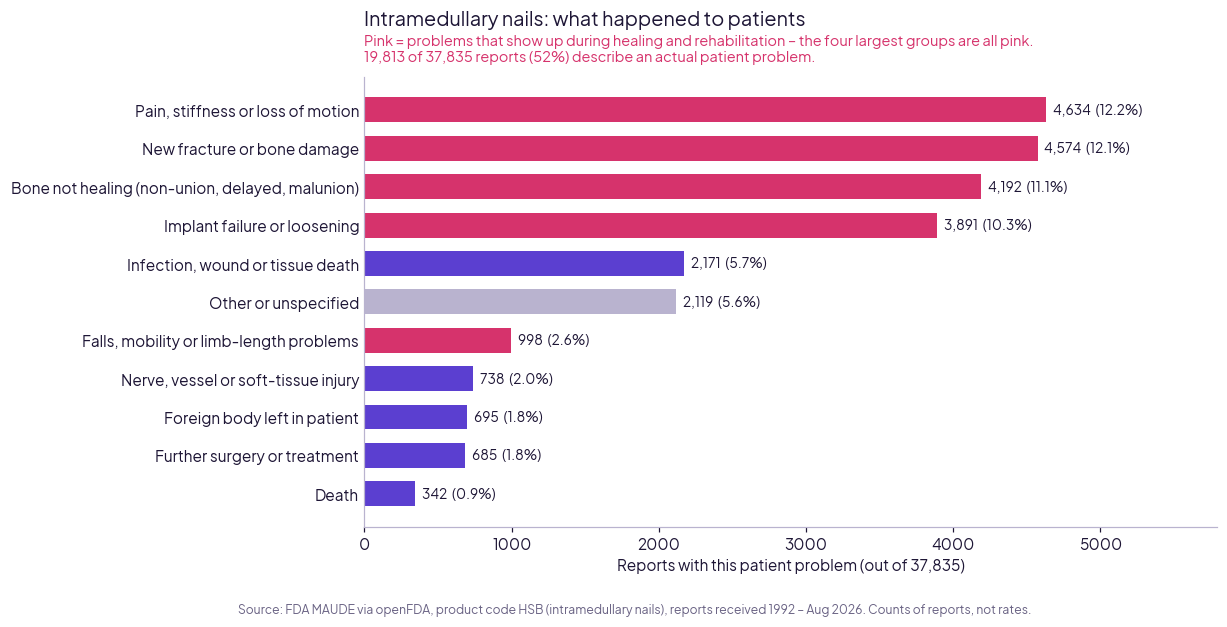

In [9]:
# 9.1 Chart theme, save helper, and chart 1: patient problems by clinical category
import matplotlib.pyplot as plt
from matplotlib import font_manager
import urllib.request, os
os.makedirs(FIG, exist_ok=True)

try:                                                    # expo theme font, default font if download fails
    font_path = '/content/PlusJakartaSans.ttf'
    urllib.request.urlretrieve('https://github.com/google/fonts/raw/main/ofl/plusjakartasans/PlusJakartaSans%5Bwght%5D.ttf', font_path)
    font_manager.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
except Exception:
    print('Theme font not loaded, using default font')

PURPLE, VIOLET, BLUE, PINK = '#3B1E8C', '#5B3FD0', '#4C7BF5', '#D6336C'
GREY, INK, MUTED = '#B9B3CF', '#1E1636', '#6B6485'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': GREY,
                     'axes.labelcolor': INK, 'text.color': INK, 'xtick.color': INK, 'ytick.color': INK,
                     'axes.titleweight': 'bold', 'axes.titlesize': 13, 'axes.titlelocation': 'left',
                     'font.size': 10, 'figure.dpi': 110})
SOURCE = 'Source: FDA MAUDE via openFDA, product code HSB (intramedullary nails), reports received 1992 – Aug 2026. Counts of reports, not rates.'

def save_fig(fig, name):
    fig.text(0.01, 0.005, SOURCE, fontsize=8, color=MUTED, ha='left', va='bottom')
    fig.savefig(f'{FIG}/{name}.png', dpi=200, bbox_inches='tight', facecolor='white')
    print('Saved figures/' + name + '.png')

HEALING = ['Bone not healing (non-union, delayed, malunion)', 'Implant failure or loosening',
           'New fracture or bone damage', 'Falls, mobility or limb-length problems', 'Pain, stiffness or loss of motion']
plot = cat.sort_values()
saved = pd.read_csv(f'{CLEAN}/clinical_categories.csv').set_index('category')['reports']
gate(plot.to_dict() == saved.reindex(plot.index).to_dict(), 'chart numbers equal the saved table')

colours = [PINK if c in HEALING else (GREY if c == OTHER else VIOLET) for c in plot.index]
fig, ax = plt.subplots(figsize=(10, 5.6))
bars = ax.barh(plot.index, plot.values, color=colours, height=0.65)
for b, v in zip(bars, plot.values):
    ax.text(v + plot.max() * 0.01, b.get_y() + b.get_height() / 2, f'{v:,}  ({v / TOTAL * 100:.1f}%)', va='center', fontsize=9)
ax.set_xlim(0, plot.max() * 1.25)
ax.set_xlabel(f'Reports with this patient problem (out of {TOTAL:,})')
ax.tick_params(axis='y', length=0)
ax.set_title('Intramedullary nails: what happened to patients', pad=34)
ax.text(0, 1.035, 'Pink = problems that show up during healing and rehabilitation – the four largest groups are all pink.\n'
                  f'{harmed_total:,} of {TOTAL:,} reports ({harmed_total / TOTAL * 100:.0f}%) describe an actual patient problem.',
        transform=ax.transAxes, fontsize=9.5, color=PINK)
fig.subplots_adjust(bottom=0.15)
save_fig(fig, '09_1_patient_problems_by_category')
plt.show()

### Chart 9.2 – When and why nails break
**Left:** all breakage reports by timing (Step 7). **Right:** of the nails that broke inside the patient after surgery, how many reports also mention bone not healing, walking / weight-bearing, or a patient fall. These are minimums, because many reports do not state a cause. The subtitle quotes real report descriptions.

**Gates:** the numbers drawn equal the saved tables exactly.

GATE PASSED: left panel numbers equal breakage_timing.csv
GATE PASSED: right panel numbers equal breakage_after_surgery.csv
Saved figures/09_2_nail_breakage_story.png


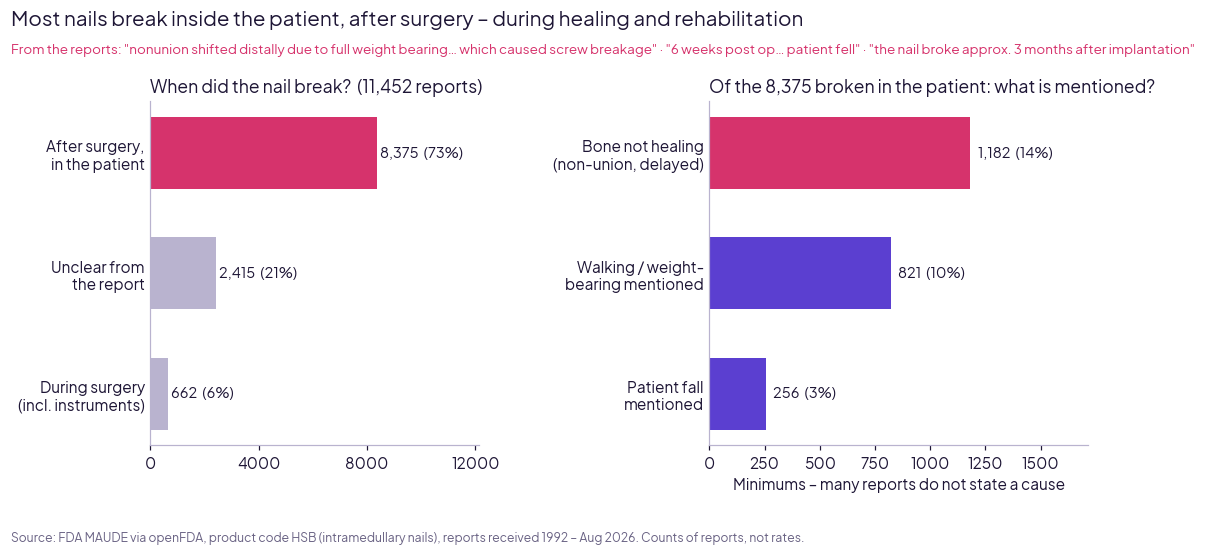

In [10]:
# 9.2 Chart 2: when nails break, and what is mentioned for nails broken in the patient
from matplotlib.ticker import MaxNLocator

saved_t = pd.read_csv(f'{CLEAN}/breakage_timing.csv').set_index('timing')['reports']
saved_a = pd.read_csv(f'{CLEAN}/breakage_after_surgery.csv').set_index('group')['reports']
gate(timing_counts.to_dict() == saved_t.to_dict(), 'left panel numbers equal breakage_timing.csv')
gate(summary7.to_dict() == saved_a.to_dict(), 'right panel numbers equal breakage_after_surgery.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={'width_ratios': [1, 1.15], 'wspace': 0.65})

order1 = ['During surgery (incl. instruments)', 'Unclear from the report', 'After surgery, in the patient']
v1 = timing_counts.reindex(order1)
total_break = int(v1.sum())
b1 = ax1.barh(['During surgery\n(incl. instruments)', 'Unclear from\nthe report', 'After surgery,\nin the patient'],
              v1.values, color=[GREY, GREY, PINK], height=0.6)
for b, v in zip(b1, v1.values):
    ax1.text(v + total_break * 0.01, b.get_y() + b.get_height() / 2, f'{v:,}  ({v / total_break * 100:.0f}%)', va='center', fontsize=9.5)
ax1.set_xlim(0, v1.max() * 1.45)
ax1.xaxis.set_major_locator(MaxNLocator(4))
ax1.set_title(f'When did the nail break?  ({total_break:,} reports)', fontsize=11.5)
ax1.tick_params(axis='y', length=0)

order2 = ['patient fall mentioned', 'loading mentioned', 'with bone not healing']
v2 = summary7.reindex(order2)
b2 = ax2.barh(['Patient fall\nmentioned', 'Walking / weight-\nbearing mentioned', 'Bone not healing\n(non-union, delayed)'],
              v2.values, color=[VIOLET, VIOLET, PINK], height=0.6)
for b, v in zip(b2, v2.values):
    ax2.text(v + m * 0.004, b.get_y() + b.get_height() / 2, f'{v:,}  ({v / m * 100:.0f}%)', va='center', fontsize=9.5)
ax2.set_xlim(0, v2.max() * 1.45)
ax2.set_title(f'Of the {m:,} broken in the patient: what is mentioned?', fontsize=11.5)
ax2.tick_params(axis='y', length=0)
ax2.set_xlabel('Minimums – many reports do not state a cause')

fig.suptitle('Most nails break inside the patient, after surgery – during healing and rehabilitation', x=0.01, ha='left',
             fontsize=13.5, fontweight='bold', y=1.06)
fig.text(0.01, 0.975, 'From the reports: "nonunion shifted distally due to full weight bearing… which caused screw breakage" · '
                      '"6 weeks post op… patient fell" · "the nail broke approx. 3 months after implantation"',
         fontsize=8.8, color=PINK, ha='left')
fig.subplots_adjust(bottom=0.2)
save_fig(fig, '09_2_nail_breakage_story')
plt.show()

## Step 10 – Key findings

**1. Scope.** 37,835 FDA reports for intramedullary nails (product code HSB), received 1992 – Aug 2026. Every one of the 35 years was checked against the FDA's own count.

**2. More than half describe harm to the patient.** 52.4% of reports (19,813) describe an actual patient problem, and 66% are filed as injuries – far more than for robotic surgery systems, because a nail stays in the bone for months while the fracture heals.

**3. The four largest patient problems are all about healing and recovery:** pain, stiffness or loss of motion (4,634) · new fracture or bone damage (4,574) · **bone not healing** – non-union, delayed union, malunion (4,192) · implant failure or loosening (3,891).

**4. Nails mostly break inside the patient, after surgery.** 11,452 reports describe a nail or part breaking or bending. **73% (8,375)** broke inside the patient after the operation; only 6% (662) broke during surgery, mostly instruments.

**5. Breakage is linked to non-healing, loading and falls.** Of the nails that broke in the patient, at least **14%** of reports also record bone not healing, **10%** mention walking or weight-bearing, and **3%** a patient fall. One report states the mechanism directly: *"nonunion shifted distally due to full weight bearing… which caused screw breakage."*

**6. Deaths need careful reading.** 115 reports are filed as deaths. Many nail patients are elderly people with hip fractures, so a death after surgery is often caused by age and other illnesses, not necessarily the device.

### What this means for rehabilitation
- **Progress weight-bearing according to bone healing**, not only the calendar: a nail can carry the load for a while, but not indefinitely if the bone does not unite.
- **Persistent pain at the fracture site, new pain while stepping or a limp that does not improve** are warning signs of non-union or implant failure; they should be reported to the surgeon early, before the nail breaks.
- **Fall prevention** is part of fracture care, especially in older patients with hip fractures and weak bone (osteoporosis).

### Limitations
- **Counts, not rates:** the FDA does not publish how many nails are implanted, so brands or products cannot be compared on safety.
- MAUDE reports are **unverified and incomplete**; product code HSB also includes **instruments** (e.g. insertion handles, drills).
- The non-healing, loading and fall shares are **minimums**: many reports are very short and do not state a cause.
- These reports are about **global brands** (e.g. Synthes, Stryker, Smith & Nephew, Zimmer Biomet); the patterns apply to intramedullary nails in general, not to one manufacturer.

In [11]:
# 10.1 Recalculate every headline number from the data (so the README and one-pager match the notebook)
facts = {
    'Reports (product code HSB)':                    f'{len(nails):,}  ({nails["year"].min()} – {nails["year"].max()})',
    'Actual patient problem':                        f'{harmed_total:,} ({harmed_total / TOTAL * 100:.1f}%)',
    'Filed as injury':                               f'{(nails["event_type"] == "Injury").mean() * 100:.0f}%',
    'Pain, stiffness or loss of motion':             f'{cat["Pain, stiffness or loss of motion"]:,}',
    'New fracture or bone damage':                   f'{cat["New fracture or bone damage"]:,}',
    'Bone not healing':                              f'{cat["Bone not healing (non-union, delayed, malunion)"]:,}',
    'Implant failure or loosening':                  f'{cat["Implant failure or loosening"]:,}',
    'Breakage reports':                              f'{len(brk):,}',
    'Broken in the patient after surgery':           f'{m:,} ({m / len(brk) * 100:.0f}%)',
    'Broken during surgery':                         f'{timing_counts["During surgery (incl. instruments)"]:,} ({timing_counts["During surgery (incl. instruments)"] / len(brk) * 100:.0f}%)',
    'After-surgery breakage + bone not healing':     f'{summary7["with bone not healing"]:,} ({summary7["with bone not healing"] / m * 100:.0f}%)',
    'After-surgery breakage + loading mentioned':    f'{summary7["loading mentioned"]:,} ({summary7["loading mentioned"] / m * 100:.0f}%)',
    'After-surgery breakage + patient fall':         f'{summary7["patient fall mentioned"]:,} ({summary7["patient fall mentioned"] / m * 100:.0f}%)',
    'Filed as death':                                f'{(nails["event_type"] == "Death").sum():,}',
}
gate(len(nails) == TOTAL, 'report total matches finding 1')
gate(cat.drop(OTHER).sort_values(ascending=False).index[:4].tolist() ==
     ['Pain, stiffness or loss of motion', 'New fracture or bone damage',
      'Bone not healing (non-union, delayed, malunion)', 'Implant failure or loosening'],
     'the four largest categories are the ones named in finding 3, in that order')

for k, v in facts.items():
    print(f'{k:<45} {v}')

GATE PASSED: report total matches finding 1
GATE PASSED: the four largest categories are the ones named in finding 3, in that order
Reports (product code HSB)                    37,835  (1992 – 2026)
Actual patient problem                        19,813 (52.4%)
Filed as injury                               66%
Pain, stiffness or loss of motion             4,634
New fracture or bone damage                   4,574
Bone not healing                              4,192
Implant failure or loosening                  3,891
Breakage reports                              11,452
Broken in the patient after surgery           8,375 (73%)
Broken during surgery                         662 (6%)
After-surgery breakage + bone not healing     1,182 (14%)
After-surgery breakage + loading mentioned    821 (10%)
After-surgery breakage + patient fall         256 (3%)
Filed as death                                115
